<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/ExampleNotebook_Autoencoder_23521013_AriefPurnamaMuharram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy
!pip install matplotlib
!pip install keras

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
print('NumPy version:', __import__('numpy').__version__)
print('Matplotlib version:', __import__('matplotlib').__version__)
print('Keras version:', __import__('keras').__version__)

NumPy version: 1.21.6
Matplotlib version: 3.2.2
Keras version: 2.9.0


In [3]:
from keras.layers import Dense,Conv2D,MaxPooling2D,UpSampling2D
from keras import Input, Model
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [4]:
encoding_dim = 15 
input_img = Input(shape=(784,))
# encoded representation of input
encoded = Dense(encoding_dim, activation='relu')(input_img)
# decoded representation of code 
decoded = Dense(784, activation='sigmoid')(encoded)
# Model which take input image and shows decoded images
autoencoder = Model(input_img, decoded)

In [5]:
# This model shows encoded images
encoder = Model(input_img, encoded)
# Creating a decoder model
encoded_input = Input(shape=(encoding_dim,))
# last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# decoder model
decoder = Model(encoded_input, decoder_layer(encoded_input))

In [6]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [7]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


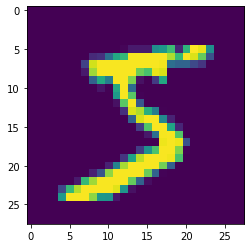

In [8]:
plt.imshow(x_train[0].reshape(28,28))

In [9]:
autoencoder.fit(x_train, x_train,
                epochs=25,
                batch_size=256,
                validation_data=(x_test, x_test))

Epoch 1/25
235/235 [==============================] - 4s 14ms/step - loss: 0.3101 - val_loss: 0.2190
Epoch 2/25
235/235 [==============================] - 3s 13ms/step - loss: 0.1992 - val_loss: 0.1835
Epoch 3/25
235/235 [==============================] - 6s 24ms/step - loss: 0.1760 - val_loss: 0.1668
Epoch 4/25
235/235 [==============================] - 5s 23ms/step - loss: 0.1622 - val_loss: 0.1558
Epoch 5/25
235/235 [==============================] - 5s 23ms/step - loss: 0.1533 - val_loss: 0.1493
Epoch 6/25
235/235 [==============================] - 5s 23ms/step - loss: 0.1484 - val_loss: 0.1455
Epoch 7/25
235/235 [==============================] - 4s 18ms/step - loss: 0.1455 - val_loss: 0.1432
Epoch 8/25
235/235 [==============================] - 3s 12ms/step - loss: 0.1434 - val_loss: 0.1414
Epoch 9/25
235/235 [==============================] - 3s 12ms/step - loss: 0.1417 - val_loss: 0.1398
Epoch 10/25
235/235 [==============================] - 3s 12ms/step - loss: 0.1402 - val_lo

313/313 [==============================] - 1s 2ms/step


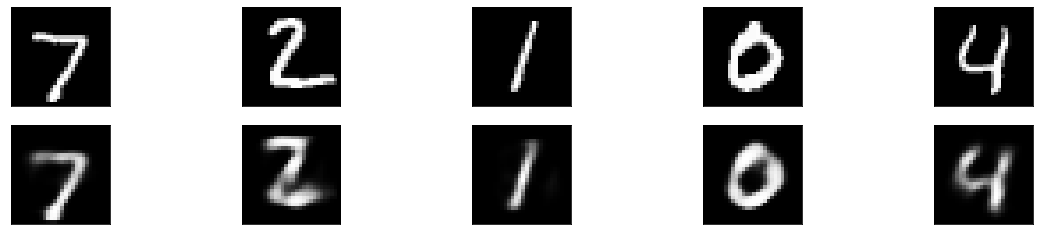

In [10]:
encoded_img = encoder.predict(x_test)
decoded_img = decoder.predict(encoded_img)
plt.figure(figsize=(20, 4))
for i in range(5):
    # Display original
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    # Display reconstruction
    ax = plt.subplot(2, 5, i + 1 + 5)
    plt.imshow(decoded_img[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

**Reference**
https://www.analyticsvidhya.com/blog/2021/06/complete-guide-on-how-to-use-autoencoders-in-python/